In [45]:
import slangpy
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import os 
cwd = Path(os.getcwd())

device = slangpy.create_device(slangpy.DeviceType.vulkan)
program = (cwd / "GGXPrecompute.slang").as_posix()    

integrateGGX_E = device.create_compute_kernel(device.load_program(program, ["integrateGGX_E"]))    
integrateGGX_Eavg = device.create_compute_kernel(device.load_program(program, ["integrateGGX_Eavg"]))
integrateGGX_IOR_E = device.create_compute_kernel(device.load_program(program, ["integrateGGX_IOR_E"]))
integrateGGX_IOR_Eavg = device.create_compute_kernel(device.load_program(program, ["integrateGGX_IOR_Eavg"]))


ggx_E = device.create_buffer(element_count=32*32, struct_size=8, format=slangpy.Format.rg32_float, usage=slangpy.BufferUsage.unordered_access)
ggx_Eavg = device.create_buffer(element_count=32, struct_size=4, format=slangpy.Format.r32_float, usage=slangpy.BufferUsage.unordered_access)
ggx_IOR_E = device.create_buffer(element_count=16*16*16, struct_size=4, format=slangpy.Format.r32_float, usage=slangpy.BufferUsage.unordered_access)
ggx_IOR_Eavg = device.create_buffer(element_count=32*32, struct_size=4, format=slangpy.Format.r32_float, usage=slangpy.BufferUsage.unordered_access)
ggx_IOR_inv_E = device.create_buffer(element_count=16*16*16, struct_size=4, format=slangpy.Format.r32_float, usage=slangpy.BufferUsage.unordered_access)
ggx_IOR_inv_Eavg = device.create_buffer(element_count=32*32, struct_size=4, format=slangpy.Format.r32_float, usage=slangpy.BufferUsage.unordered_access)


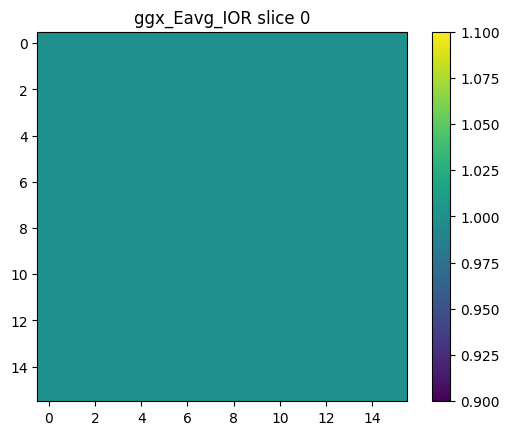

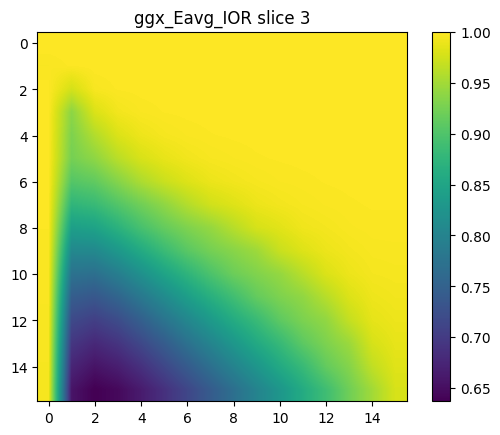

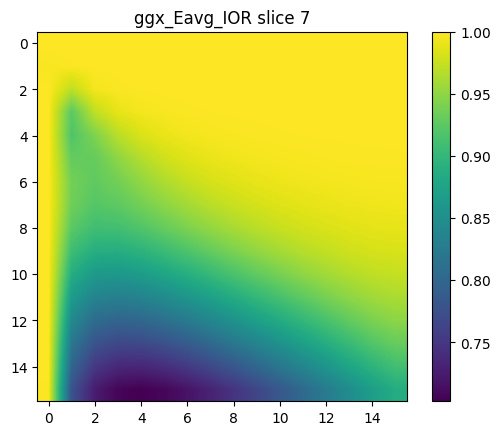

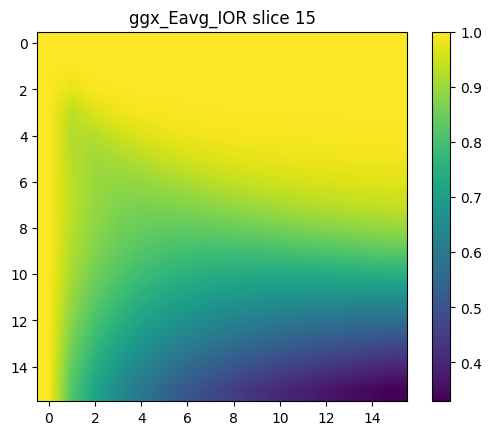

In [46]:
# Eavg IOR
integrateGGX_IOR_E.dispatch(thread_count=[1,1,16],vars={"ggxEIOR": ggx_IOR_E, "inverse": False})
im_ggx_Eavg_IOR = ggx_IOR_E.to_numpy().reshape(16,16,16)
for slice in [0, 3, 7, 15]:
    plane = im_ggx_Eavg_IOR[slice,:,:]
    plt.imshow(plane, interpolation='bilinear')
    plt.title(f'ggx_Eavg_IOR slice {slice}')
    plt.colorbar()
    plt.show()


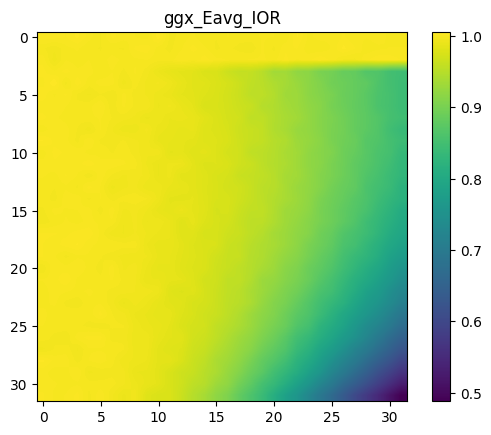

In [47]:
# Eavg
integrateGGX_IOR_Eavg.dispatch(thread_count=[1,1,1],vars={"ggxEIORavg": ggx_IOR_Eavg, "inverse": False})
im_ggx_Eavg_IOR = ggx_IOR_Eavg.to_numpy().reshape(32,32)
plt.imshow(im_ggx_Eavg_IOR, interpolation='bilinear')
plt.title('ggx_Eavg_IOR')
plt.colorbar()
plt.show()

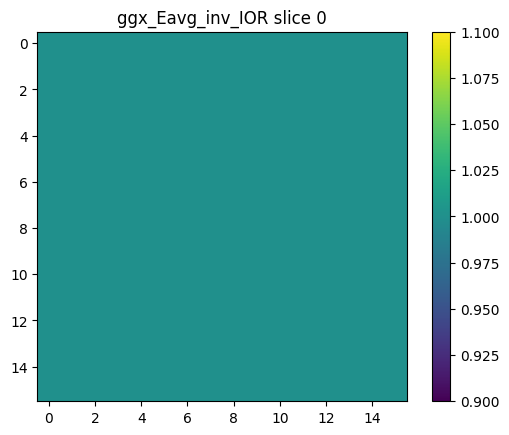

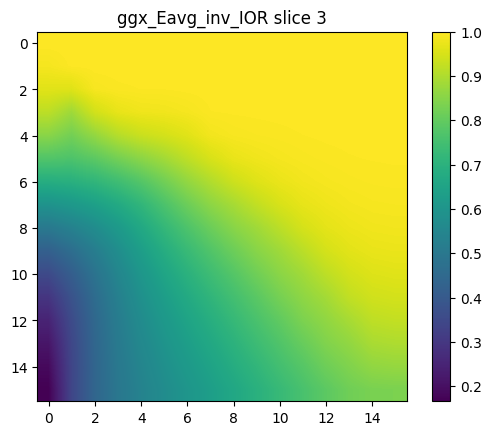

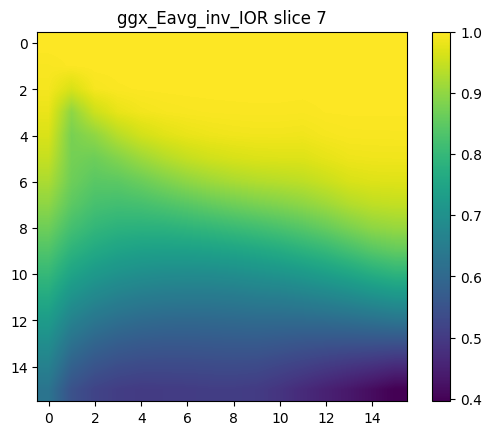

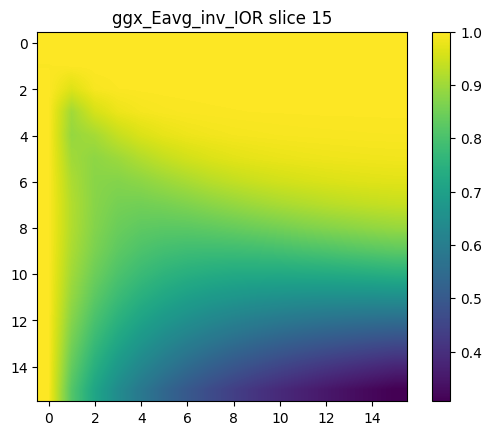

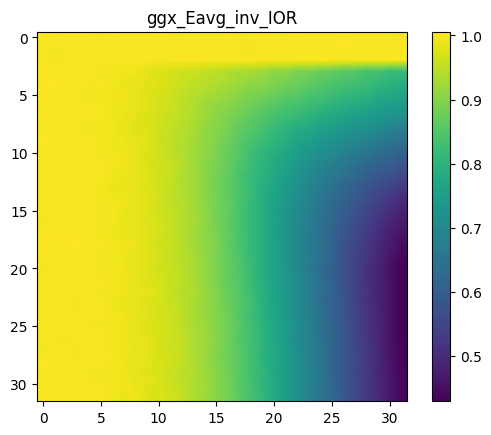

In [48]:
# 1/IOR for both above
# Eavg IOR
integrateGGX_IOR_E.dispatch(thread_count=[1,1,16],vars={"ggxEIOR": ggx_IOR_inv_E, "inverse": True})
im_ggx_Eavg_IOR = ggx_IOR_inv_E.to_numpy().reshape(16,16,16)
for slice in [0, 3, 7, 15]:
    plane = im_ggx_Eavg_IOR[slice,:,:]
    plt.imshow(plane, interpolation='bilinear')
    plt.title(f'ggx_Eavg_inv_IOR slice {slice}')
    plt.colorbar()
    plt.show()

integrateGGX_IOR_Eavg.dispatch(thread_count=[1,1,1],vars={"ggxEIORavg": ggx_IOR_inv_Eavg, "inverse": True})
im_ggx_Eavg_IOR = ggx_IOR_inv_Eavg.to_numpy().reshape(32,32)
plt.imshow(im_ggx_Eavg_IOR, interpolation='bilinear')
plt.title('ggx_Eavg_inv_IOR')
plt.colorbar()
plt.show()

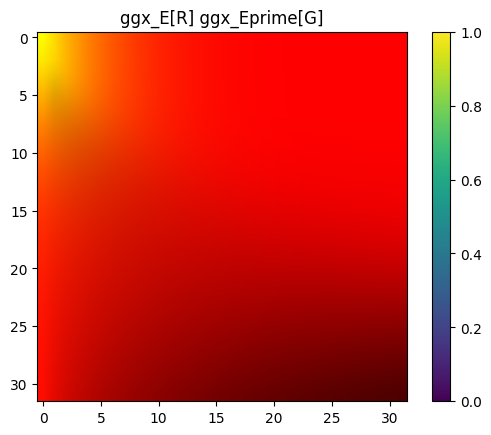

In [49]:
# E
integrateGGX_E.dispatch(thread_count=[1,1,1],vars={"ggxE": ggx_E})
im_ggx_E = ggx_E.to_numpy().reshape(32, 32, 2)
im_ggx_E = np.dstack([im_ggx_E, np.zeros((32, 32, 1), dtype=im_ggx_E.dtype)])
plt.imshow(im_ggx_E, interpolation='bilinear')
plt.title('ggx_E[R] ggx_Eprime[G]')
plt.colorbar()
plt.show()

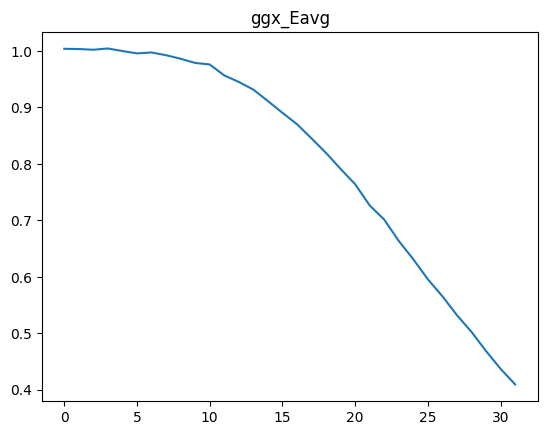

In [50]:
# Eavg
integrateGGX_Eavg.dispatch(thread_count=[1,1,1],vars={"ggxEavg": ggx_Eavg})
im_ggx_Eavg = ggx_Eavg.to_numpy()
plt.plot(im_ggx_Eavg)
plt.title('ggx_Eavg')
plt.show()

In [51]:
# Dump to file
with open("../Source/Renderer/Tables/GGX_IOR.hpp", "w") as f:
    f.write("#pragma once\n")
    f.write("// Generated by Scripts/GGXPrecompute.ipynb\n")
    f.write("constexpr float kGGXlutEIOR[16 * 16 * 16] = {\n\t")
    for i, v in enumerate(ggx_IOR_E.to_numpy().flatten()):
        f.write(f"{v:.6f}f,{' ' if (i+1) % 16 else '\n\t'}")
    f.write("\n};\n")
    f.write("constexpr float kGGXlutEIORavg[32 * 32] = {\n\t")
    for i, v in enumerate(ggx_IOR_Eavg.to_numpy().flatten()):
        f.write(f"{v:.6f}f,{' ' if (i+1) % 32 else '\n\t'}")
    f.write("\n};\n")
    f.write("constexpr float kGGXlutEInvIOR[16 * 16 * 16] = {\n\t")
    for i, v in enumerate(ggx_IOR_inv_E.to_numpy().flatten()):
        f.write(f"{v:.6f}f,{' ' if (i+1) % 16 else '\n\t'}")
    f.write("\n};\n")
    f.write("constexpr float kGGXlutEInvIORavg[32 * 32] = {\n\t")
    for i, v in enumerate(ggx_IOR_inv_Eavg.to_numpy().flatten()):
        f.write(f"{v:.6f}f,{' ' if (i+1) % 32 else '\n\t'}")
    f.write("\n};\n")    

In [52]:
with open("../Source/Renderer/Tables/GGX.hpp", "w") as f:
    f.write("#pragma once\n")
    f.write("// Generated by Scripts/GGXPrecompute.ipynb\n")
    f.write("constexpr float /* RG32 */ kGGXlutE[32 * 32 * 2] = {\n\t")
    for i, v in enumerate(ggx_E.to_numpy().flatten()):
        f.write(f"{v:.6f}f,{' ' if (i+1) % 32 else '\n\t'}")
    f.write("\n};\n")
    f.write("constexpr float /* R32 */ kGGXlutEavg[32] = {\n\t")
    for i, v in enumerate(ggx_Eavg.to_numpy().flatten()):
        f.write(f"{v:.6f}f,{' ' if (i+1) % 32 else '\n\t'}")
    f.write("\n};\n")